# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [ ]:
# Install any dependencies not pre-installed on Colab
!pip install -q anthropic python-dotenv
print("✅ Dependencies ready")

✅ Dependencies ready


In [ ]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [ ]:
# ── Label map for TakeMeter (3 discourse-quality labels) ──────────────────
# Keys are the string labels in dataset.csv; values are integer ids from 0.
# See planning.md §2 for full definitions.
# ──────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "critical_analysis": 0,   # structured argument backed by specific evidence
    "visceral_reaction": 1,   # immediate emotional/physical felt response
    "hot_take":          2,   # bold unsupported opinion stated as fact
}

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")


Labels: {'critical_analysis': 0, 'visceral_reaction': 1, 'hot_take': 2}
Number of labels: 3


In [ ]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving dataset.csv to dataset (1).csv
Uploaded: dataset (1).csv


In [ ]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['text', 'label', 'notes']
Total examples: 217

Label distribution:
label
critical_analysis    86
visceral_reaction    68
hot_take             63
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [ ]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 151 examples
Validation: 33 examples
Test: 33 examples

Train label distribution:
label
critical_analysis    60
visceral_reaction    47
hot_take             44
Name: count, dtype: int64

Test label distribution:
label
critical_analysis    13
visceral_reaction    11
hot_take              9
Name: count, dtype: int64


In [ ]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

Map:   0%|          | 0/151 [00:00<?, ? examples/s]

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

Map:   0%|          | 0/33 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [ ]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.089014,1.094357,0.393939
2,1.083401,1.080452,0.393939
3,1.070053,1.054617,0.393939


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [ ]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.394

Per-class metrics (fine-tuned model):
                   precision    recall  f1-score   support

critical_analysis       0.39      1.00      0.57        13
visceral_reaction       0.00      0.00      0.00        11
         hot_take       0.00      0.00      0.00         9

         accuracy                           0.39        33
        macro avg       0.13      0.33      0.19        33
     weighted avg       0.16      0.39      0.22        33



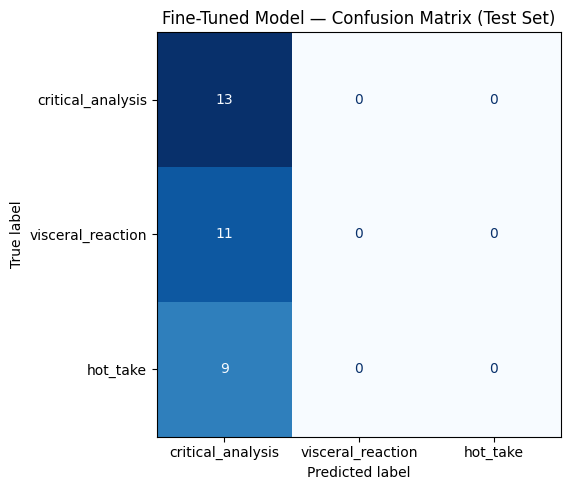

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [ ]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [ ]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 20 / 33

--- #1 ---
Text:      Evil Dead Rise, first one I have ever watched, wasn't sure what to expect, I watch lots of horrors, I can't explain fully why but this film terrified and freaked me out the whole way though. Did you l...
True:      visceral_reaction
Predicted: critical_analysis  (confidence: 0.36)

--- #2 ---
Text:      Why is Appalachian horror so popular? - Hey, I'm not here to bash this subgenre, but I'm German and just confused that so many horror stories are set in one specific mountain range.  What makes it so ...
True:      visceral_reaction
Predicted: critical_analysis  (confidence: 0.38)

--- #3 ---
Text:      Alyce Kills, Contracted, Almost Mercy (or poorly rated horror movies you enjoy) - I love these movies. Contracted was rated better than the other two IIRC so maybe it doesn't fit, but I love them. Bee...
True:      visceral_reaction
Predicted: critical_analysis  (confidence: 0.36)

--- #4 ---
Text:      You know what I love? That creeping

---
## Section 5: Baseline Classifier (Anthropic Claude)

Runs your zero-shot baseline using `claude-haiku-4-5-20251001`.  
You need to write the classification prompt using your label definitions.

In [ ]:
import anthropic
from google.colab import userdata

# Option A — Colab Secrets (recommended, do NOT commit key to GitHub):
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named ANTHROPIC_API_KEY with your key as the value
#   3. Enable notebook access for the secret
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")

# Option B — paste directly (do not commit to GitHub):
# ANTHROPIC_API_KEY = "your_anthropic_api_key_here"

assert ANTHROPIC_API_KEY, (
    "ANTHROPIC_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access, or use Option B above."
)

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
print("✅ Anthropic client initialized")

✅ Anthropic client initialized


In [ ]:
# Classification prompt for the Groq zero-shot baseline.
# Definitions copied from planning.md §2; one example post per label.

SYSTEM_PROMPT = """You are classifying posts from horror film and literature subreddits (e.g. r/horror, r/HorrorLit) by their DISCOURSE QUALITY.
Assign each post to exactly one of the following three categories.

critical_analysis: The post makes a structured argument about a work's themes, craft, pacing, subtext, or lore, backed by specific examples or reasoning. The point is to argue or analyze, not just assert or react.
Example: "The Descent isn't just about monsters; the cave is a physical manifestation of Sarah's grief after the crash, and every tightening passage mirrors how the film withholds her recovery."

visceral_reaction: An immediate emotional or physical response to a work (fear, disgust, awe, excitement, boredom). The focus is the personal felt experience, not analyzing why the work succeeds, and not a debatable value claim.
Example: "Just watched Event Horizon for the first time, where has this movie been my whole life??? So fun and gory, great cast."

hot_take: A bold, confident, often contrarian opinion stated as fact, with little to no supporting evidence. The post asserts a debatable value judgment rather than arguing it or just emoting.
Example: "Drag Me To Hell is the most underrated horror film of the 2000s, full stop."

Rules:
- If a claim is supported with specific evidence/reasoning, it is critical_analysis, even if it is framed as a "hot take".
- If the core is a debatable judgment about quality ("overrated", "the best") with thin support, it is hot_take.
- If the core is the writer's felt experience with no real argument, it is visceral_reaction.

Respond with ONLY the label name (critical_analysis, visceral_reaction, or hot_take).
Do not explain your reasoning."""
print("System prompt set.")


System prompt set.


In [ ]:
def classify_with_claude(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=20,
            system=SYSTEM_PROMPT,
            messages=[
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
        )
        raw = response.content[0].text.strip().lower()
        # Match longest labels first so a label that is a substring of another
        # can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_claude(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 33 examples...
(May take a few minutes — 0.1s delay between requests)

  10/33 complete...
  20/33 complete...
  30/33 complete...


In [ ]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.788  (evaluated on 33/33 parseable responses)

Per-class metrics (baseline):
                   precision    recall  f1-score   support

critical_analysis       0.90      0.69      0.78        13
visceral_reaction       0.89      0.73      0.80        11
         hot_take       0.64      1.00      0.78         9

         accuracy                           0.79        33
        macro avg       0.81      0.81      0.79        33
     weighted avg       0.83      0.79      0.79        33



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [ ]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<40} {'Accuracy':>8}")
print("-" * 50)
print(f"{'Zero-shot baseline (Claude Haiku)':<40} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<40} {ft_accuracy:>8.3f}")
print("-" * 50)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                                    Accuracy
--------------------------------------------------
Zero-shot baseline (Claude Haiku)           0.788
Fine-tuned DistilBERT                       0.394
--------------------------------------------------

Fine-tuning regression: 0.394

Use these numbers in your README evaluation report.


In [ ]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


In [ ]:
sample_posts = [
    "The Descent isn't just a monster movie — the cave is a physical manifestation of Sarah's grief, and every tightening passage mirrors how the film refuses to let her recover.",
    "Just finished Hereditary for the first time. I literally could not breathe during the attic scene. That film is going to haunt me for weeks.",
    "Midsommar is the most overrated A24 film, period. Beautiful to look at, but completely hollow.",
    "What I love about Shirley Jackson is how she weaponizes domesticity — the house in Hill House isn't just haunted, it's a trap built from the architecture of repression.",
]
for post in sample_posts:
    inputs = tokenizer(post, return_tensors="pt", truncation=True, max_length=256).to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.nn.functional.softmax(logits, dim=-1).squeeze().tolist()
    pred_id = probs.index(max(probs))
    print(f"Post: {post[:90]}...")
    print(f"Predicted: {ID_TO_LABEL[pred_id]}  (confidence: {max(probs):.2f})")
    print()


Post: The Descent isn't just a monster movie — the cave is a physical manifestation of Sarah's g...
Predicted: critical_analysis  (confidence: 0.36)

Post: Just finished Hereditary for the first time. I literally could not breathe during the atti...
Predicted: critical_analysis  (confidence: 0.37)

Post: Midsommar is the most overrated A24 film, period. Beautiful to look at, but completely hol...
Predicted: critical_analysis  (confidence: 0.35)

Post: What I love about Shirley Jackson is how she weaponizes domesticity — the house in Hill Ho...
Predicted: critical_analysis  (confidence: 0.36)

